In [72]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
import requests

%load_ext autoreload 
%autoreload 2

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
COLABFOLD_OUTPUT_DIR = '../data/genes/colabfold/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 7].copy()
genes_df['alphafold_id'] = genes_df.genome_id.apply(lambda genome_id : f'{genome_id}_cluster_7_1mer')

FASTAFile.from_df(genes_df).write('../data/genes/cluster_7.faa')
# subprocess.run('muscle -align ../data/genes/cluster_7.faa -output ../data/genes/cluster_7.afa', shell=True, check=True)
msa = MSAFile.from_file('../data/genes/cluster_7.afa')

for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_7 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_7 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_82
orfm.bz_1.1_43
orfm.bz_2.1_117
orfm.bz_3.1_142
orfm.bz_5.1_26
orfm.bz_7.1_68
orfm.bz_8.1_106
orfm.bz_9.1_152
orfm.bz_10.1_110
orfm.bz_11.1_147

Minimum cluster_7 gene length: 207
Maximum cluster_7 gene length: 311


In [3]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
for row in genes_df.itertuples():
    print(f'Number TMHs in {row.genome_id} cluster_1 protein:', row.num_tmhs)

Number TMHs in bz_0 cluster_1 protein: 0
Number TMHs in bz_1 cluster_1 protein: 0
Number TMHs in bz_2 cluster_1 protein: 0
Number TMHs in bz_3 cluster_1 protein: 0
Number TMHs in bz_5 cluster_1 protein: 0
Number TMHs in bz_7 cluster_1 protein: 0
Number TMHs in bz_8 cluster_1 protein: 0
Number TMHs in bz_9 cluster_1 protein: 0
Number TMHs in bz_10 cluster_1 protein: 0
Number TMHs in bz_11 cluster_1 protein: 0


In [18]:
outputs = [AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id)) for gene_id in genes_df.index]
# outputs = [ColabFoldOutput(os.path.join(COLABFOLD_OUTPUT_DIR, get_genome_id(gene_id), gene_id)) for gene_id in genes_df.index]
# Substantial improvement with the custom MSAFiles! The improvement in pTM is likely due to the addition of the custom MSAFiles, not differences between the 
# AlphaFold2 and AlphaFold3 architectures, see Peng et. al. 2025 (https://pmc.ncbi.nlm.nih.gov/articles/PMC12661943/)

for output in outputs:
    print(output.name, output.get_ptms(best_model=True))

orfm.bz_0.1_82 0.57
orfm.bz_1.1_43 0.61
orfm.bz_2.1_117 0.59
orfm.bz_3.1_142 0.59
orfm.bz_5.1_26 0.6
orfm.bz_7.1_68 0.59
orfm.bz_8.1_106 0.57
orfm.bz_9.1_152 0.53
orfm.bz_10.1_110 0.53
orfm.bz_11.1_147 0.56


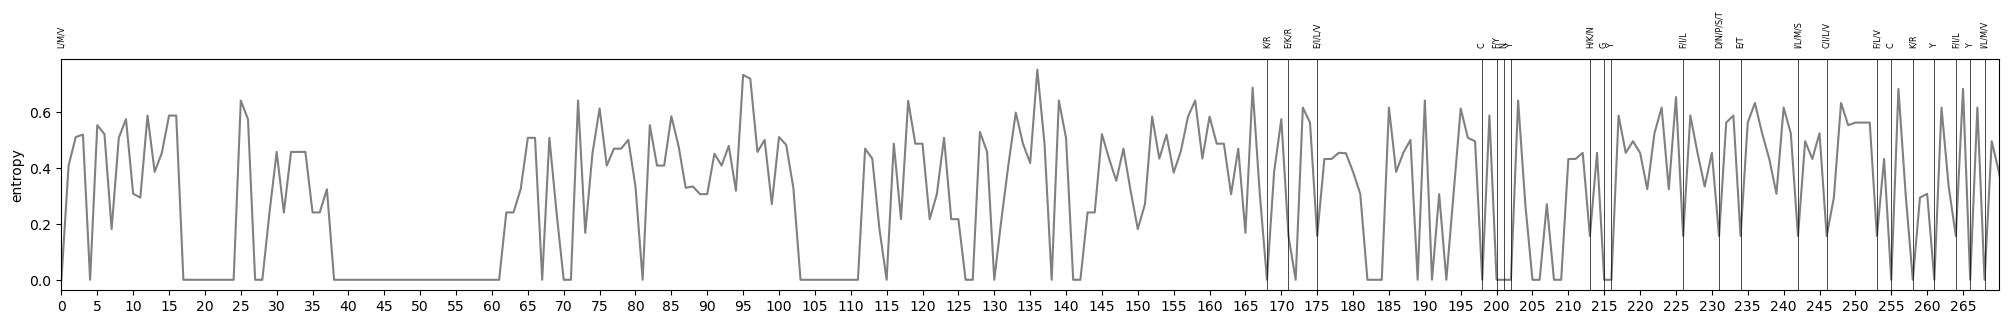

0	 ... . HHHHHH...H...HHH.HHHHHHHHHHHS ....TT  ..........  S HHHHHHHHHHHHHHHHHH. GGGHHHH    HHHHHHHHHHHHHHHHH  HHHHHHHHHHHHHHTTEETT..EE  HHHHHHHHHHHTT .	150	orfm.bz_5.1_140
0	 ... .    ...... ...  PPPHHHHHHHHHHHH....HH...H   .... TT  HHHHHHHHHHHHHHHHHH. GGGTTTT    HHHHHHHHHHHHHHHHH  HHHHHHHHHHHHHHTT  SS..S   HHHHHHHHTT    .	150	orfm.bz_3.1_50
0	 ... .   PPP ...    TT   HHHHHHHIIIII....STTSTTSPPS TTSSS  HHHHHHHHHHHHHHHHHH. GGGTTTS    HHHHHHHHHHHHHHHHH  HHHHHHHHHHHHHHTT   TT     HHHHHHHHHHHTT .	150	orfm.bz_4.1_164
0	 ... .       ... ...TTS  HHHHHHHHHHHH....STTSTT   S .. TTTHHHHHHHHHHHHHHHHHHH. GGGHHHH    HHHHHHHHHHHHHHHHH  HHHHHHHHHHHHHHTT   TT     HHHHHHHHT     .	150	orfm.bz_0.1_175
0	 ... .    ...... ...TTS  HHHHHHHHHHH ....TTTSTTPPPSS.TT SPPHHHHHHHHHHHHHHHHHH. GGGHHHH    HHHHHHHHHHHHHHHHH  HHHHHHHHHHHHHHTT SSTTPPP  HHHHHHHHHHTTT .	150	orfm.bz_11.1_39
0	     .       PPPP...TTS  HHHHHHHHHHHH....HH...HS ......TTS HHHHHHHHHHHHHHHHHH. GGGHHHH    HHHHHHHHHHHHHHHHH  HHHHHHHHHHHHHHTT  TT...S 

In [ ]:
# Based on the Foldseek hits, it seems like this protein could interact with Zinc. Are there conserved Cys or His residues?
# Two conserved cysteines is not necessarily a zinc-binding domain. though perhaps the alignment failed? 

# There is very little conservation at all on the N-terminus... but is the structure conserved? Yes! Remarkable conservation, mostly helices.

MAX_ENTROPY = 0.2
msa = MSAFile.from_file(path='../data/genes/cluster_7.afa')

def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_array(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSAFile.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSAFile.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))

# x_min, x_max = 240, 270
x_min, x_max = 0, 270
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
ax.plot(np.arange(len(entropy)), entropy, color='gray')

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSAFile.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

ax.set_xticks(np.arange(x_min, x_max, 5))
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

msa = MSAFile.from_file('../data/genes/cluster_1.afa')
dssp_msa = map_dssp_to_msa(msa)

dssp_msa.show(start=0, stop=150)

In [ ]:

FOLDSEEK_FIELD_MAP = dict()
FOLDSEEK_FIELD_MAP['query'] = 'query_id'
FOLDSEEK_FIELD_MAP['target'] = 'target_id'
FOLDSEEK_FIELD_MAP['evalue'] = 'e_value'
FOLDSEEK_FIELD_MAP['gapopen'] = 'num_gaps'
FOLDSEEK_FIELD_MAP['pident'] = 'percent_identity'
FOLDSEEK_FIELD_MAP['fident'] = 'fraction_identical'
FOLDSEEK_FIELD_MAP['nident'] = 'num_identical'
FOLDSEEK_FIELD_MAP['qstart'] = 'query_start'
FOLDSEEK_FIELD_MAP['qend'] = 'query_end'
FOLDSEEK_FIELD_MAP['qlen'] = 'query_length'
FOLDSEEK_FIELD_MAP['tstart'] = 'target_start'
FOLDSEEK_FIELD_MAP['tend'] = 'target_end'
FOLDSEEK_FIELD_MAP['tlen'] = 'target_length'
FOLDSEEK_FIELD_MAP['alnlen'] = 'alignment_length'
FOLDSEEK_FIELD_MAP['bits'] = 'bit_score'
FOLDSEEK_FIELD_MAP['cigar'] = 'cigar'
FOLDSEEK_FIELD_MAP['qseq'] = 'query_seq'
FOLDSEEK_FIELD_MAP['tseq'] = 'target_seq'
FOLDSEEK_FIELD_MAP['qheader'] = 'query_header'
FOLDSEEK_FIELD_MAP['theader'] = 'target_header'
FOLDSEEK_FIELD_MAP['qaln'] = 'query_alignment'
FOLDSEEK_FIELD_MAP['taln'] = 'target_alignment'
FOLDSEEK_FIELD_MAP['mismatch'] = 'num_mismatches'
FOLDSEEK_FIELD_MAP['qcov'] = 'query_coverage'
FOLDSEEK_FIELD_MAP['tcov'] = 'target_coverage'
FOLDSEEK_FIELD_MAP['taxid'] = 'taxonomy_id'
FOLDSEEK_FIELD_MAP['taxname'] = 'taxonomy'
FOLDSEEK_FIELD_MAP['taxlineage'] = 'lineage'
FOLDSEEK_FIELD_MAP['lddt'] = 'lddt'
FOLDSEEK_FIELD_MAP['lddtfull'] = 'lddt_full'
FOLDSEEK_FIELD_MAP['qtmscore'] = 'query_tm_score'
FOLDSEEK_FIELD_MAP['ttmscore'] = 'target_tm_score'
FOLDSEEK_FIELD_MAP['alntmscore'] = 'alignment_tm_score'
FOLDSEEK_FIELD_MAP['rmsd'] = 'rmsd'
FOLDSEEK_FIELD_MAP['prob'] = 'probability'

FOLDSEEK_FIELDS = 'query target evalue gapopen pident fident nident qstart qend qlen tstart tend tlen alnlen bits cigar qseq tseq qheader theader qaln taln mismatch qcov tcov taxid taxname taxlineage lddt lddtfull qtmscore ttmscore alntmscore rmsd prob'
FOLDSEEK_FIELDS = [FOLDSEEK_FIELD_MAP.get(field) for field in FOLDSEEK_FIELDS.split(' ')]

foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]

target_header_map = dict()
target_header_map['A0A8S5LVD6'] = 'Zinc ribbon domain protein'
target_header_map['A0A7L7SSE5'] = 'Uncharacterized protein' 
target_header_map['A0A8S5RLS8'] = 'Uncharacterized protein' 

foldseek_search_df['target_header'] = foldseek_search_df.target_header.apply(lambda header : target_header_map.get(header, header))


In [130]:
filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
# filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 100
filters['synthetic'] = foldseek_search_df.target_header.str.contains('De novo design')

foldseek_search_df = apply_filters(filters, foldseek_search_df)
print('Leftmost alignment start:', foldseek_search_df.query_start.min())
print('Leftmost alignment end:', foldseek_search_df.query_end.min())


# Pretty much all of these hits are DNA polymerase, and are to the C-terminus of the protein. But what about te N-terminus?
# N terminus looks like a transcription factor, C-terminus like DNA polymerase.

# Zinc ribbon domain protein 
categories = dict()
categories['DNA polymerase'] = foldseek_search_df.target_header.str.contains('DNA polymerase|MsDpo4|ImuB|polymerase-DNA', case=False) # ImuB is a specialized, catalytically inactive Y-family DNA polymerase.  
categories['DNA methylase'] = foldseek_search_df.target_header.str.contains('methylase', case=False)
# categories['UmuC'] = foldseek_search_df.target_header.str.contains('UmuC domain-containing protein') # A UmuC domain-containing protein is part of a family of enzymes involved in DNA repair.
categories['translesion synthesis'] = foldseek_search_df.target_header.str.contains('UmuC|MutS|ImpB|DNA repair|UvrX|UV-damage', case=False)
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False)
categories['terminase'] = foldseek_search_df.target_header.str.contains('terminase', case=False)
categories['transcription factor'] = foldseek_search_df.target_header.str.contains('transcription factor|zinc|C2H2')
categories['DUF4113 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF4113') # This domain of unknown function is usually found at the C terminus of DNA repair polymerase proteins.
categories['UvrA'] = foldseek_search_df.target_header.str.contains('Excinuclease ABC subunit A|UvrA') # The UvrA subunit associates with the UvrB subunit in the form of an A2B1 complex which, guided by UvrA's affinity for damaged DNA binds to a lesion in DNA and delivers the UvrB subunit to the damaged site. https://pubmed.ncbi.nlm.nih.gov/2204825/
categories['ImsC-like protein'] = foldseek_search_df.target_header.str.contains('ImsC-like') # These are involved in DNA damage repair, see https://www.ebi.ac.uk/interpro/entry/pfam/PF11799/
categories['paired box protein'] = foldseek_search_df.target_header.str.contains('Pax', case=False) # This is a transcription factor, and is the main source of N-terminal hits. 

foldseek_search_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')

apply_filters: 0 entries removed by low_tm_score.
apply_filters: 0 entries removed by short_alignment.
apply_filters: 0 entries removed by synthetic.
Leftmost alignment start: 1
Leftmost alignment end: 50


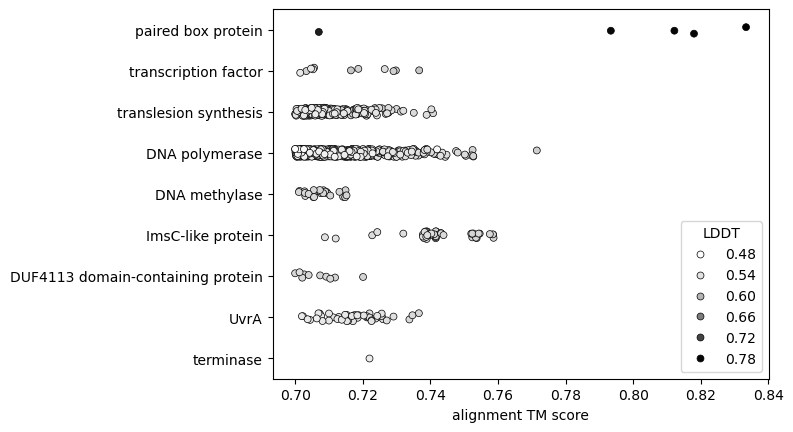

In [131]:
fig, ax = plt.subplots()

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')
plt.show()

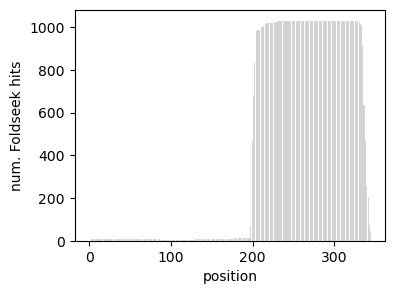

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = foldseek_search_df.copy()
figure_df = foldseek_search_df.drop_duplicates('target_id')
# Get the indices relative to the MSAFile. 
figure_df['msa_start'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_start, row.query_id), axis=1) 
figure_df['msa_stop'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_end, row.query_id), axis=1) 

positions = np.arange(msa.n_cols)
heights = np.zeros(len(positions))
for row in figure_df.itertuples():
    heights[np.arange(row.msa_start, row.msa_stop)] += 1 

ax.bar(positions, heights, color='lightgray', lw=0, edgecolor='black')
ax.set_ylabel('num. Foldseek hits')
ax.set_xlabel('position')
plt.show()
